In [1]:
# rewritten manually from ../../notebooks/model_probe_transfer/*
data = {
    "Llama 3.2 (3B)": [0.0, 97.8, 99.6, 99.7, 94.8, 99.9, 99.4, 96.6, 99.8, 98.9, 99.6, 98.2, 99.4, 99.9, 99.9, 99.7, 99.1, 99.9, 99.2, 99.9, 99.6, 99.8, 96.0, 99.1, 99.6, 97.8, 97.1, 84.7, 0.2],
    "Phi 4 (15B)": [62, 83, 95, 99, 99.6, 99.3, 97.0, 97.4, 96.4, 95.4, 98.6, 97.4, 99.7, 99.1, 99.6, 96.7, 98.2, 91.8, 96.2, 97.1, 98.1, 99.2, 98.7, 95.9, 98.2, 97.2, 98.7, 98.4, 97.2, 96.0, 96.9, 98.1, 97.3, 96.6, 95.7, 93.4, 95.1, 95.2, 93.1, 83.9, 86.1],
    "Olmo (13B)": [84.6, 99.7, 98.2, 94.5, 97.0, 99.2, 96.9, 97.4, 97.6, 98.6, 99.2, 97.3, 96.9, 98.0, 96.2, 97.0, 98.6, 97.9, 96.8, 95.2, 98.6, 99.0, 99.2, 99.3, 96.3, 99.1, 97.3, 97.6, 93.9, 98.0, 95.4, 94.1, 94.8, 93.2, 91.3, 93.0, 90.5, 86.0, 91.3, 58.8, 13.2]
}

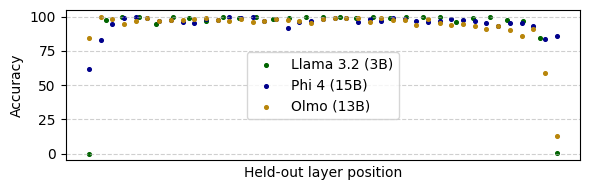

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# --- Settings ---
colors = ["#006400", "#00008B", "#B8860B"]  # Dark green, dark blue, dark yellow
target_len = max(len(v) for v in data.values())

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 2))  # wider canvas

for (label, y), color in zip(data.items(), colors):
    x = np.linspace(0, target_len - 1, len(y))
    ax.scatter(x, y, label=label, color=color, s=7, marker="o")

# Add margins around points
ax.set_xlim(-2, target_len + 1)
ax.set_ylim(min(min(vals) for vals in data.values()) - 5,
            max(max(vals) for vals in data.values()) + 5)

ax.set_title("")
ax.set_xlabel("Held-out layer position")
ax.set_ylabel("Accuracy")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="center")
ax.set_xticks([])

fig.tight_layout()
plt.savefig("held_out_accuracies_3models.pdf", format="pdf")

plt.show()